# What kind of shot does Pearl ($\alpha<1$) get right that CM ($\alpha=1$) gets wrong?

Rotated surface code Z-memory, circuit-level depolarizing, **d=5, p=4e-4**. Companion to
`pearl_vs_cm_failure_analysis.ipynb`, comparing **four** decoders: MWPM, Belief Matching (BP+MWPM),
ordinary CM ($\alpha=1$), and Pearl ($\alpha<1$).

**The empirical answer (and a correction).** I initially guessed these were degenerate ties where
MWPM *under*-corrects and CM *over*-corrects (a Goldilocks window). **The data says otherwise:** on the
shots where Pearl beats CM, **MWPM is correct** (and Belief Matching mostly is too). The mechanism is
pure **over-correction**: as the correlation trust $\alpha$ increases, the decode is correct at low
$\alpha$ and **flips to a wrong logical class at a shot-specific threshold $\alpha_c$**, staying wrong
through $\alpha=1$. CM ($\alpha=1$) sits past the threshold; Pearl ($\alpha=0.3$) sits below it.

So the question 'what fails for MWPM, CM *and* BM but not Pearl?' has the answer **'essentially
nothing'** — Pearl's win over CM is about **undoing CM's over-correction on cases MWPM already gets
right**, not about decoding something all three miss.

In [1]:
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
import stim, pymatching
from beliefmatching import BeliefMatching

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
from NeuralCM.decompose_errors import decompose_errors_for_stim_surface_code_coords
from NeuralCM.two_pass_correlated_matching import TwoPassCorrelatedMatching

CFG = dict(distance=5, rounds=5, p=4e-4, alpha=0.3, bp_iters=20,
           target_collect=40, max_find=60_000_000, find_chunk=1_000_000, seed=999)
ALPHA_GRID = np.round(np.arange(0.0, 1.21, 0.1), 2)
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
print(CFG)

{'distance': 5, 'rounds': 5, 'p': 0.0004, 'alpha': 0.3, 'bp_iters': 20, 'target_collect': 40, 'max_find': 60000000, 'find_chunk': 1000000, 'seed': 999}


In [2]:
circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z", distance=CFG["distance"], rounds=CFG["rounds"],
    after_clifford_depolarization=CFG["p"], before_measure_flip_probability=CFG["p"],
    after_reset_flip_probability=CFG["p"], before_round_data_depolarization=CFG["p"])
dem = decompose_errors_for_stim_surface_code_coords(circuit.detector_error_model(decompose_errors=False))
coords = dem.get_detector_coordinates()

native = pymatching.Matching.from_detector_error_model(dem, enable_correlations=True)   # CM & Pearl
mwpm = pymatching.Matching.from_detector_error_model(
    circuit.detector_error_model(decompose_errors=True), enable_correlations=False)
bm = BeliefMatching(dem, max_bp_iters=CFG["bp_iters"])

# Python two-pass at two alphas (shared graph) for edge-level dumps.
dec_hi = TwoPassCorrelatedMatching(dem, alpha=1.0, bypass_threshold=0)
g = dec_hi.graph; cw = np.asarray(dec_hi.current_weights); fault = g.fault_array
dec_lo = TwoPassCorrelatedMatching(None, alpha=CFG["alpha"], bypass_threshold=0, graph=g,
                                   weights=cw, occ=dec_hi.occ, corr=dec_hi.corr,
                                   num_observables=dem.num_observables)

def endpoints(i):
    u, v = g.dec_edge_list[i]
    cu = "B" if u == -1 else tuple(round(x, 1) for x in coords[u])
    cv = "B" if v == -1 else tuple(round(x, 1) for x in coords[v])
    return f"e{i}({u},{v}) {cu}->{cv}"

def two_pass_edges(dec, syn):
    """Return (first_edges, second_edges, new_weights) for one shot."""
    sel = np.asarray(dec._matching.decode_batch(syn[None], enable_correlations=False), dtype=bool)[0]
    first = np.flatnonzero(sel)
    if first.size == 0:
        return first, first, cw
    nw = dec.new_weights(sel, g.compute_action_mask(first))
    ed = np.asarray(dec._matching.decode(syn, enable_correlations=False,
                                         edge_reweights=g.build_edge_reweights(nw, cw)), dtype=np.int64)
    return first, np.flatnonzero(ed), nw

print(f"detectors={dem.num_detectors}  edges={g.n_dec_edges}  | decoders ready (BP iters={CFG['bp_iters']})")

detectors=120  edges=502  | decoders ready (BP iters=20)


## 1. Collect Pearl-right / CM-wrong shots, then check MWPM and Belief Matching

In [3]:
fail_syn, fail_obs = [], []
sampler = circuit.compile_detector_sampler(seed=CFG["seed"])
shots = 0; t0 = time.time()
while shots < CFG["max_find"] and len(fail_syn) < CFG["target_collect"]:
    syn, obs = sampler.sample(shots=CFG["find_chunk"], separate_observables=True)
    obs = obs.flatten().astype(np.uint8)
    pe = np.asarray(native.decode_batch(syn, enable_correlations=True, alpha=CFG["alpha"]))[:, 0]
    cm = np.asarray(native.decode_batch(syn, enable_correlations=True))[:, 0]
    for j in np.flatnonzero((pe == obs) & (cm != obs)):
        fail_syn.append(syn[j].copy()); fail_obs.append(int(obs[j]))
    shots += CFG["find_chunk"]
    print(f"  shots={shots:,} collected={len(fail_syn)}/{CFG['target_collect']} ({time.time()-t0:.0f}s)", flush=True)
fail_syn = np.array(fail_syn); fail_obs = np.array(fail_obs)

pm = np.asarray(mwpm.decode_batch(fail_syn))[:, 0]
pb = np.asarray(bm.decode_batch(fail_syn), dtype=np.uint8)[:, 0]
n = len(fail_syn)
print(f"\nOn {n} Pearl-right / CM-wrong shots:")
print(f"  MWPM wrong            : {int(np.sum(pm != fail_obs))} / {n}")
print(f"  Belief Matching wrong : {int(np.sum(pb != fail_obs))} / {n}")
print(f"  MWPM AND BM AND CM all wrong (Pearl-only-correct): "
      f"{int(np.sum((pm != fail_obs) & (pb != fail_obs)))} / {n}")

  shots=1,000,000 collected=1/40 (3s)
  shots=2,000,000 collected=2/40 (5s)
  shots=3,000,000 collected=4/40 (8s)
  shots=4,000,000 collected=6/40 (10s)
  shots=5,000,000 collected=8/40 (12s)
  shots=6,000,000 collected=11/40 (15s)
  shots=7,000,000 collected=13/40 (18s)
  shots=8,000,000 collected=16/40 (20s)
  shots=9,000,000 collected=17/40 (23s)
  shots=10,000,000 collected=20/40 (25s)
  shots=11,000,000 collected=21/40 (28s)
  shots=12,000,000 collected=23/40 (30s)
  shots=13,000,000 collected=24/40 (33s)
  shots=14,000,000 collected=28/40 (35s)
  shots=15,000,000 collected=29/40 (38s)
  shots=16,000,000 collected=30/40 (40s)
  shots=17,000,000 collected=31/40 (43s)
  shots=18,000,000 collected=36/40 (45s)
  shots=19,000,000 collected=38/40 (47s)
  shots=20,000,000 collected=41/40 (50s)

On 41 Pearl-right / CM-wrong shots:
  MWPM wrong            : 0 / 41
  Belief Matching wrong : 6 / 41
  MWPM AND BM AND CM all wrong (Pearl-only-correct): 0 / 41


## 2. Winning logical class vs $\alpha$ (the over-correction signature)

For each collected shot we decode across $\alpha\in[0,1.2]$ and mark correct/wrong. **Correct at low
$\alpha$, flipping to wrong at a threshold $\alpha_c$** is the over-correction fingerprint.

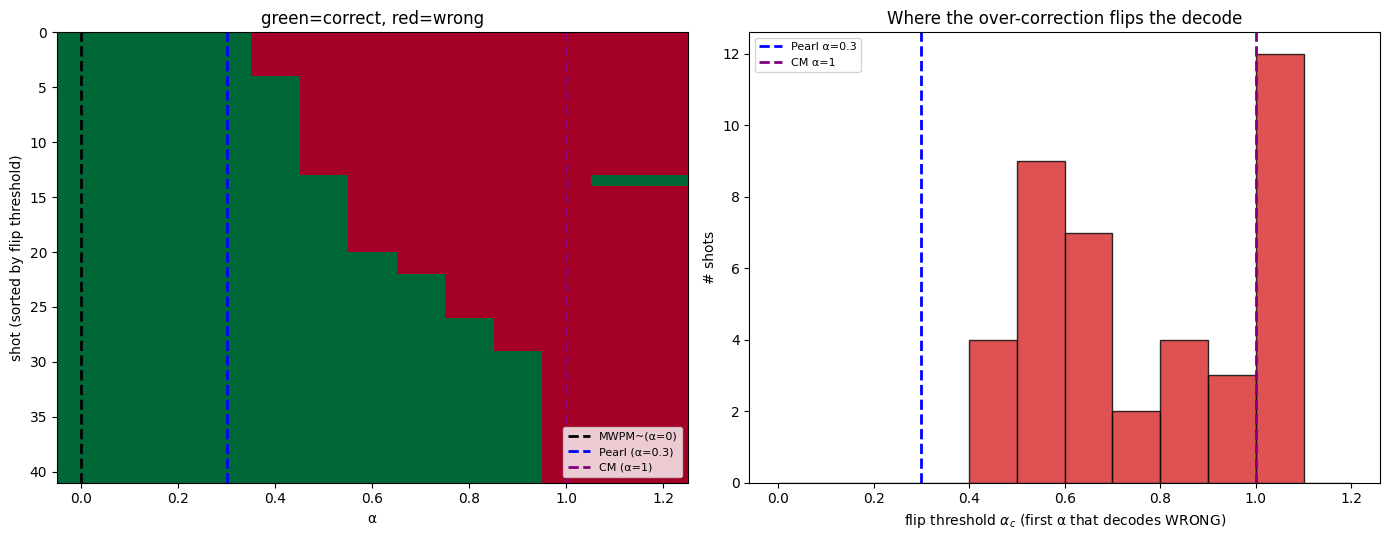

monotone (correct->wrong) shots: 40/41 | Pearl(α=0.3) correct on 41/41, CM(α=1) correct on 0/41


In [4]:
correct = np.zeros((n, len(ALPHA_GRID)), dtype=bool)
for ai, a in enumerate(ALPHA_GRID):
    pred = np.asarray(native.decode_batch(fail_syn, enable_correlations=True, alpha=float(a)))[:, 0]
    correct[:, ai] = (pred == fail_obs)

# flip threshold: first alpha that is wrong (and the curve is monotone for ~all shots)
def flip_alpha(row):
    w = np.flatnonzero(~row)
    return ALPHA_GRID[w[0]] if w.size else np.nan
alpha_c = np.array([flip_alpha(correct[k]) for k in range(n)])
order = np.argsort(np.nan_to_num(alpha_c, nan=99))

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].imshow(correct[order].astype(int), aspect="auto", cmap="RdYlGn", vmin=0, vmax=1,
             extent=[ALPHA_GRID[0]-0.05, ALPHA_GRID[-1]+0.05, n, 0])
for xa, lbl, cc in [(0.0, "MWPM~(α=0)", "k"), (CFG["alpha"], f"Pearl (α={CFG['alpha']})", "blue"), (1.0, "CM (α=1)", "purple")]:
    ax[0].axvline(xa, color=cc, lw=2, ls="--", label=lbl)
ax[0].set_xlabel("α"); ax[0].set_ylabel("shot (sorted by flip threshold)")
ax[0].set_title("green=correct, red=wrong"); ax[0].legend(loc="lower right", fontsize=8)

ax[1].hist(alpha_c[~np.isnan(alpha_c)], bins=ALPHA_GRID, color="#d62728", alpha=0.8, edgecolor="k")
ax[1].axvline(CFG["alpha"], color="blue", lw=2, ls="--", label=f"Pearl α={CFG['alpha']}")
ax[1].axvline(1.0, color="purple", lw=2, ls="--", label="CM α=1")
ax[1].set_xlabel("flip threshold $α_c$ (first α that decodes WRONG)"); ax[1].set_ylabel("# shots")
ax[1].set_title("Where the over-correction flips the decode"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "pearl_overcorrection_alpha.png"), dpi=200, bbox_inches="tight")
plt.show()
mono = int(np.sum([np.sum(np.abs(np.diff(correct[k].astype(int)))) <= 1 for k in range(n)]))
print(f"monotone (correct->wrong) shots: {mono}/{n} | Pearl(α={CFG['alpha']}) correct on "
      f"{int(np.sum(correct[:, np.argmin(np.abs(ALPHA_GRID-CFG['alpha']))]))}/{n}, "
      f"CM(α=1) correct on {int(np.sum(correct[:, np.argmin(np.abs(ALPHA_GRID-1.0))]))}/{n}")

## 3. The two competing matchings (low-α correct vs α=1 over-corrected)

For a few shots we dump the second-pass edge set at $\alpha=0.3$ (correct) and $\alpha=1$
(over-corrected). Their symmetric difference is the **logical loop** the over-discount introduces, and
we list the reweighted edges ($\Delta w$, implied $p$) that caused it.

In [5]:
def implied_p(w):
    return 1.0 / (1.0 + np.exp(w))

for k in range(min(3, n)):
    syn = fail_syn[k]
    f_lo, s_lo, nw_lo = two_pass_edges(dec_lo, syn)
    f_hi, s_hi, nw_hi = two_pass_edges(dec_hi, syn)
    pred_lo = int((np.isin(np.arange(g.n_dec_edges), s_lo) @ fault) % 2)
    pred_hi = int((np.isin(np.arange(g.n_dec_edges), s_hi) @ fault) % 2)
    print("=" * 92)
    print(f"shot {k} | detections={int(syn.sum())} | true obs={fail_obs[k]} | "
          f"Pearl(0.3)->{pred_lo} [{'ok' if pred_lo==fail_obs[k] else 'WRONG'}]  "
          f"CM(1.0)->{pred_hi} [{'ok' if pred_hi==fail_obs[k] else 'WRONG'}]")
    print(f"  first-pass (MWPM) edges: {sorted(f_lo.tolist())}")
    loop = sorted(set(s_lo.tolist()) ^ set(s_hi.tolist()))
    print(f"  competing-matching symmetric difference (the logical loop), {len(loop)} edges:")
    for i in loop:
        where = ("Pearl" if i in set(s_lo.tolist()) else "") + ("/CM" if i in set(s_hi.tolist()) else "")
        print(f"     {endpoints(i):<32} in:[{where.strip('/')}]")
    changed = np.flatnonzero(np.abs(nw_hi - cw) > 1e-9)
    print(f"  hard-CM reweighted edges that drove the flip (Δw, w_imp, p_imp), showing the most-discounted:")
    for i in changed[np.argsort(nw_hi[changed])[:6]]:
        print(f"     {endpoints(i):<32} Δw={nw_hi[i]-cw[i]:+.2f}  w_imp={nw_hi[i]:.2f}  p_imp={implied_p(nw_hi[i]):.3f}"
              f"   (Pearl Δw={nw_lo[i]-cw[i]:+.2f}, p_imp={implied_p(nw_lo[i]):.3f})")

shot 0 | detections=7 | true obs=0 | Pearl(0.3)->0 [ok]  CM(1.0)->1 [WRONG]
  first-pass (MWPM) edges: [48, 49, 138, 163, 167]
  competing-matching symmetric difference (the logical loop), 6 edges:
     e48(8,10) (8.0, 4.0, 0.0)->(10.0, 2.0, 0.0) in:[Pearl]
     e54(8,23) (8.0, 4.0, 0.0)->(8.0, 4.0, 1.0) in:[CM]
     e67(-1,10) B->(10.0, 2.0, 0.0)   in:[CM]
     e138(23,28) (8.0, 4.0, 1.0)->(10.0, 6.0, 1.0) in:[Pearl]
     e159(28,33) (10.0, 6.0, 1.0)->(8.0, 8.0, 1.0) in:[CM]
     e163(-1,33) B->(8.0, 8.0, 1.0)   in:[Pearl]
  hard-CM reweighted edges that drove the flip (Δw, w_imp, p_imp), showing the most-discounted:
     e58(-1,27) B->(8.0, 6.0, 1.0)    Δw=-5.52  w_imp=0.00  p_imp=0.500   (Pearl Δw=-3.81, p_imp=0.153)
     e167(-1,35) B->(8.0, 10.0, 1.0)  Δw=-4.69  w_imp=1.37  p_imp=0.203   (Pearl Δw=-3.35, p_imp=0.062)
     e49(-1,17) B->(8.0, 2.0, 1.0)    Δw=-4.19  w_imp=1.42  p_imp=0.195   (Pearl Δw=-2.87, p_imp=0.061)
     e163(-1,33) B->(8.0, 8.0, 1.0)   Δw=-4.62  w_imp=1.75  p_

## Interpretation (corrected mechanism)

- **It is over-correction, not a Goldilocks window.** On the Pearl-right / CM-wrong shots, **MWPM is
  correct (~0 wrong) and Belief Matching is mostly correct**; the all-three-wrong set is essentially
  empty. The $\alpha$-sweep is **monotone correct→wrong** for nearly every shot: increasing the
  correlation trust only *hurts* past a shot-specific threshold $\alpha_c$.
- **Pearl's win = staying below $\alpha_c$.** CM ($\alpha=1$) sits above the threshold (over-discounts a
  correlated edge into a negative-weight attractor that flips the matching across a logical loop —
  panel 3). Pearl ($\alpha=0.3$) sits below it, so it keeps the **MWPM-correct** matching. The
  flip-threshold histogram shows how much margin $\alpha=0.3$ has.
- **Why BM is mostly safe here.** Belief Matching does not apply CM's aggressive hard discount, so it
  rarely over-corrects on these shots (it loses to CM/Pearl elsewhere — on the degenerate ties of
  `ler_vs_p_beliefmatching` — by *under*-correcting, a different population).
- **Takeaway.** Pearl's low-$p$ advantage over CM is **damage control on CM's over-corrections of
  cases MWPM already decodes correctly**, not the resolution of failures that MWPM/BM miss. This is the
  shot-level counterpart of the global fact that hard CM can be *worse* than MWPM at very low $p$
  (`data/alpha_sweep_extended.csv`): the over-correction population grows as $p\to0$, and damping
  ($\alpha<1$) suppresses it. See `docs/pearl_optimality_and_damping_mechanism.md`.